In [1]:
import psutil
from functools import partial
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd

import os
import matplotlib.pyplot as plt
from glob import glob
import seaborn as sns 
from tqdm.notebook import tqdm
from matplotlib import font_manager
import scipy.stats as stats

font_path = 'Futura Book.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, size='large')
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams.update({'font.size': 12})

In [2]:
energyDF=pd.read_csv("../../../classical/energies.csv",index_col=0)

In [3]:
moldf = pd.read_csv('molecules.csv')
activespacedf = pd.read_csv("active_spaces.csv")

In [4]:
moldf.shape

(12, 5)

In [5]:
import re

def process_list(data_list):
    """
    Processes a list of strings to perform the following operations:
    1.  Strips trailing newline characters.
    2.  Parses the 'LUCJ' string into three separate elements.
    3.  Converts the final element from a string to a float.
    """
    processed_list = []
    for item in data_list:
        item = item.strip()

        if "LUCJ" in item:
            # Use a regular expression to extract the components
            match = re.search(r'(LUCJ)\(L=(.*?)\)/(.*)', item)
            if match:
                processed_list.extend(match.groups())
            else:
                processed_list.append(item)
        else:
            processed_list.append(item)
    
    # Convert the last element to a float
    # We use a try-except block in case the last element is not a number
    try:
        processed_list[-1] = float(processed_list[-1])
    except (ValueError, IndexError):
        pass # The last element is not a float, so we ignore it

    return processed_list

In [6]:
postprocessed = []
for i in tqdm(glob("./energies/*txt"),desc='Running'):
    with open(i,'r') as f:
        lines = f.readlines()

            
    moldict = pd.DataFrame.from_dict(dict(zip(["Basis Set","Molecule","Method","L","Injected","Energy"],process_list(lines))),orient='index').T
    postprocessed.append(moldict)

Running:   0%|          | 0/1080 [00:00<?, ?it/s]

In [7]:
LUCJDF=pd.concat(postprocessed).reset_index().drop(columns=['index']).astype({"L":int,"Energy":float})
LUCJDF['Method'] =[f"LUCJ(L={i})" for i in LUCJDF['L']]

In [8]:
for a,b in moldf[['molecule','mol_filename']].values:
    if 'GDB' in b:
        name = b.replace('.xyz','')
        energyDF['Molecule'] = energyDF['Molecule'].replace(name,a)

In [9]:
energyDF['L'] = len(energyDF)*[np.nan]
energyDF['Injected'] = len(energyDF)*[np.nan]

In [10]:
upDF = pd.concat([energyDF,LUCJDF]).reset_index().drop(columns=['index'])
upDF['Deviation'] = np.nan

In [11]:
uniqueBasis = energyDF['Basis Set'].unique()
uniqueMol = energyDF['Molecule'].unique()
uniqueInj = energyDF['Injected'].unique()
uniqueLayers = upDF['L'].unique()


In [12]:
uniqueMol

array(['water', 'ammonia', 'methane', 'formaldehyde', 'ethylene',
       'ethane', 'methanol', 'buta-1,3-diene', 'but-1-yne',
       'prop-2-en-1-ol', '(Z)-1-fluoroprop-1-ene', 'fluoroform'],
      dtype=object)

In [13]:
upDF['Injected'].value_counts()

Injected
CCSD        180
ML          180
ML_exact    180
MP2         180
random      180
zeroes      180
Name: count, dtype: int64

In [14]:
for mol in uniqueMol:
    for basis in uniqueBasis:
        # Get the CASCI reference energy (scalar)
        casci_row = upDF.loc[
            (upDF["Molecule"] == mol)
            & (upDF["Method"] == "CCSD")
            & (upDF["Basis Set"] == basis),
            "Energy",
        ]
        if casci_row.empty:
            continue  # skip if no CASCI reference for this (mol, basis)
        casci_e = casci_row.values[0]  # extract scalar

        # Compute deviations for other methods with the same mol/basis
        mask = (
            (upDF["Molecule"] == mol)
            & (upDF["Basis Set"] == basis)
            & (upDF["Method"] != "CCSD")
        )
        upDF.loc[mask, "Deviation"] = (upDF.loc[mask, "Energy"] - casci_e)*1e3


In [15]:
#sns.relplot(data=upDF, x="total_bill", y="tip", hue="day", col="time", row="sex")

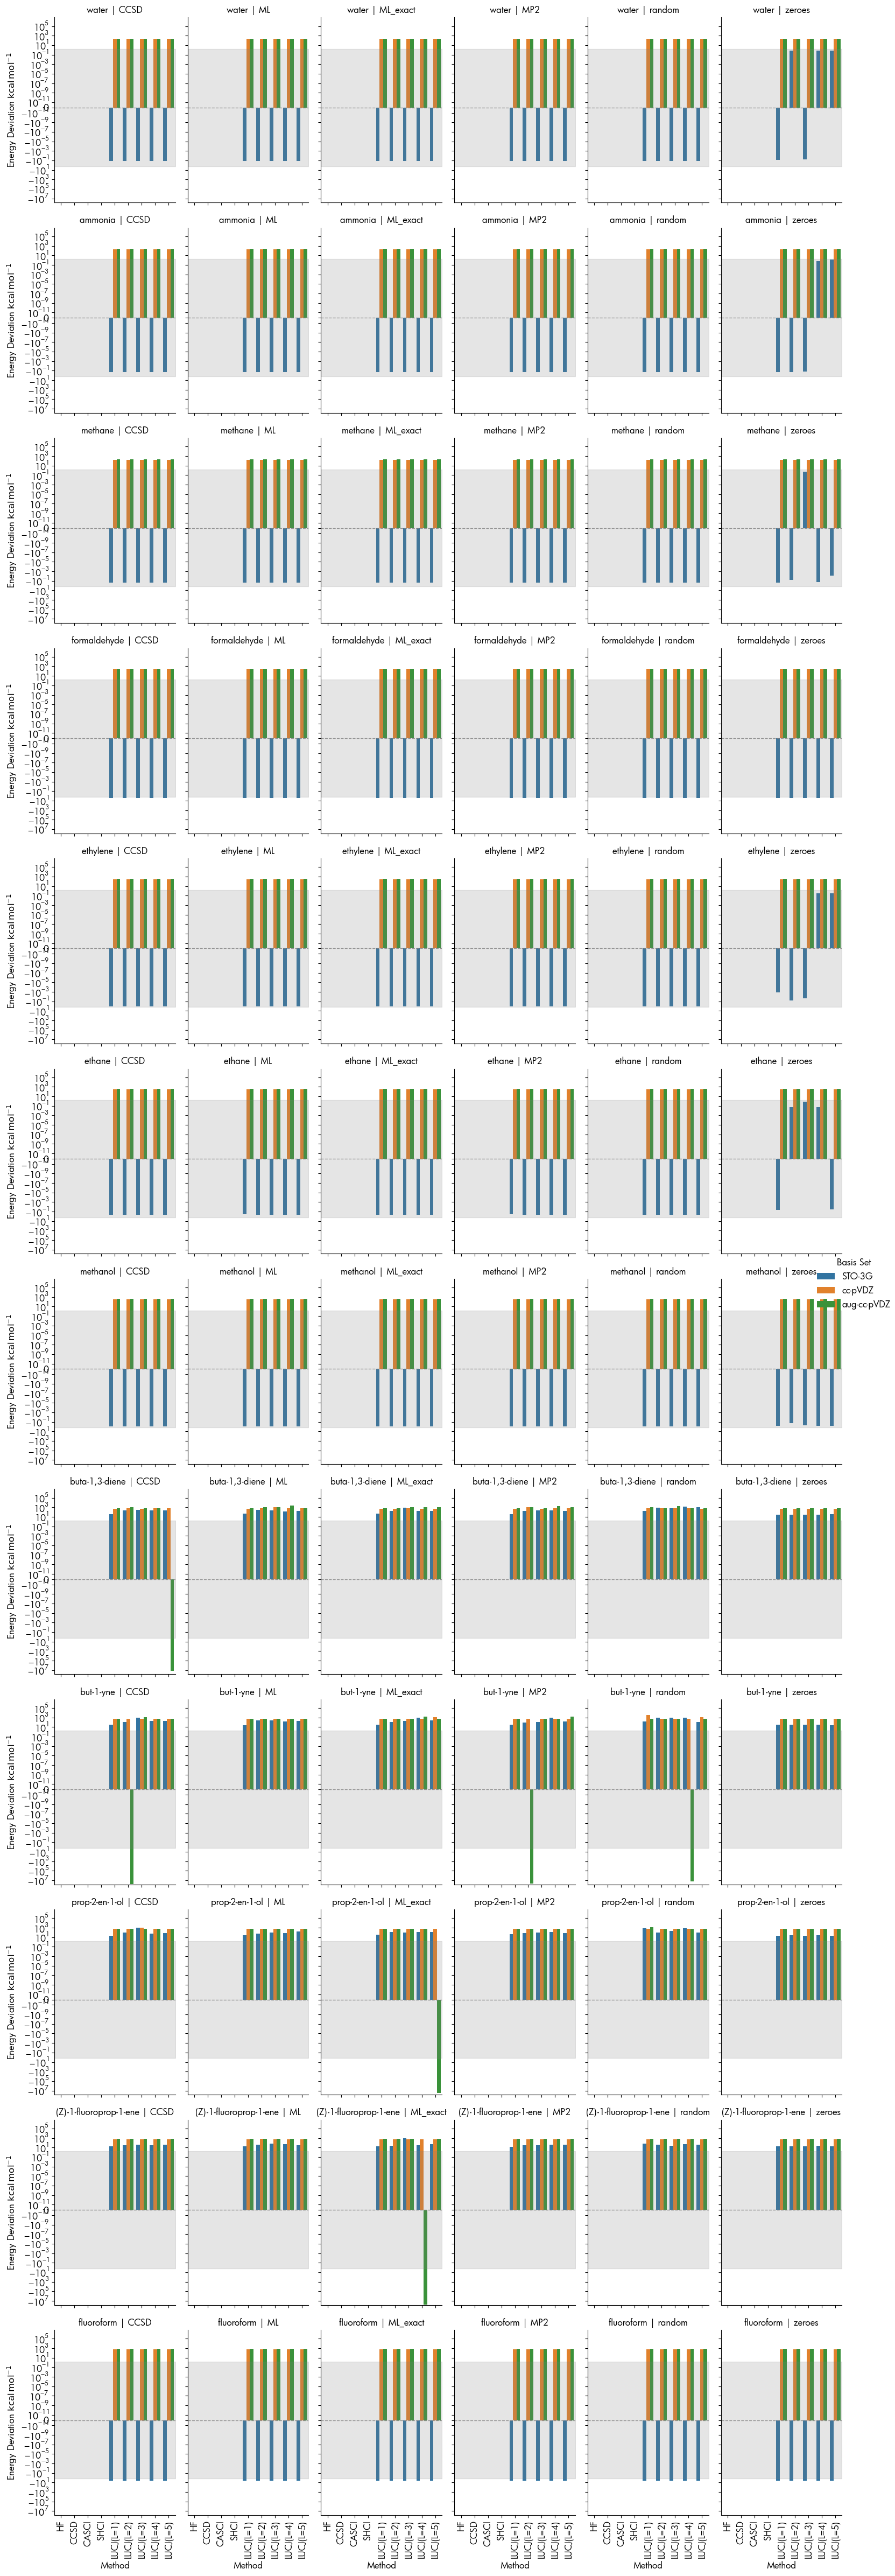

In [16]:
# Create the FacetGrid with bar plots
g = sns.catplot(
    data=upDF,
    row="Molecule",
    y="Deviation",
    x="Method",
    hue="Basis Set",
    col="Injected",
    kind="bar",
    height=4,
    aspect=0.6,
)

# Compute global deviation range for consistent shading/scaling
ymin = upDF["Deviation"].min()
ymax = upDF["Deviation"].max()
pad = 0.1 * max(abs(ymin), abs(ymax))

# Apply styling to **all subplots**
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-11)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # Gray fill region across same y-span
    ax.fill_between(
        np.linspace(-0.5, len(upDF["Method"].unique()) - 0.5, 100),
        -1.6, 1.6,
        color="gray", alpha=0.2
    )

    ax.set_xlim(-0.5, len(upDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Adjust titles and axis labels
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Method", r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")


# Move legend outside the main plot (right side)
g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)
plt.subplots_adjust(right=0.85)  # make space for legend

plt.tight_layout()
plt.show()


/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/seaborn/axisgrid.py:85

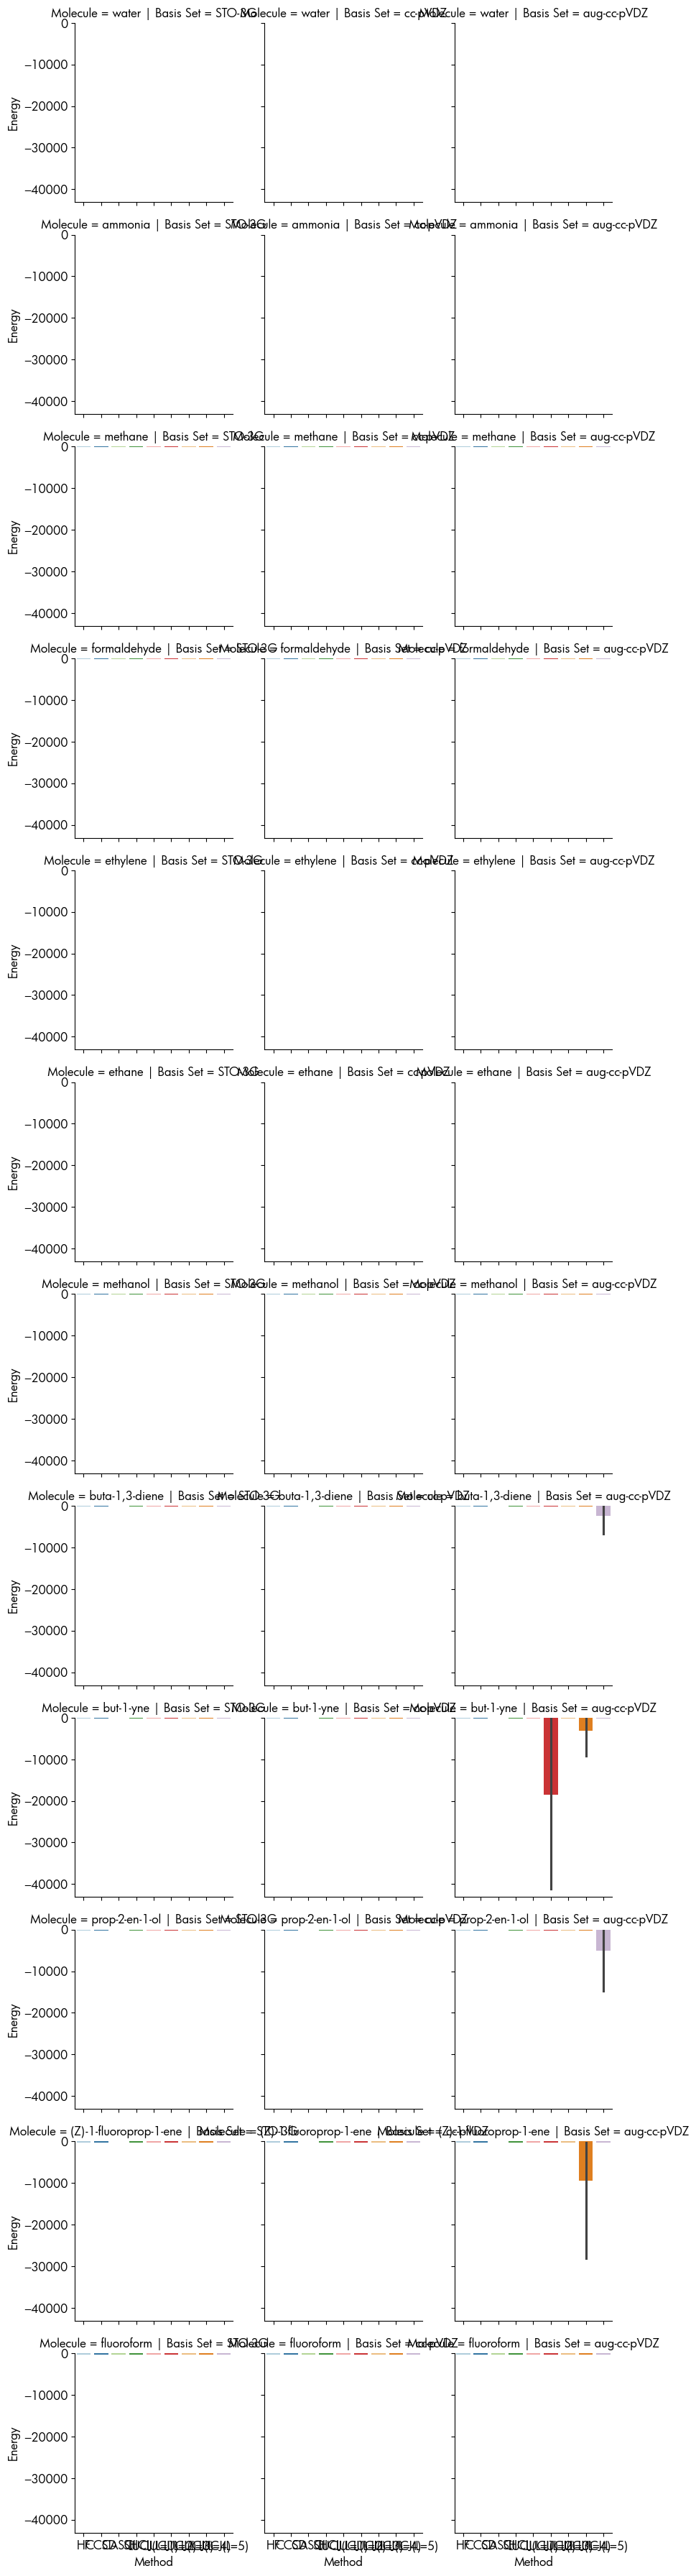

In [17]:
g = sns.FacetGrid(upDF, col="Basis Set",row='Molecule')
g.map_dataframe(sns.barplot, x="Method",y='Energy',palette="Paired")

In [18]:
# # This creates a boolean mask that is True for every row where 'Method' contains "LUCJ"
mask = upDF['Method'].str.contains("LUCJ", case=False, na=False)

# # Use the boolean mask to filter the DataFrame
filtered_df = upDF[mask]


In [19]:

# devDF = upDF[(upDF['Basis Set']=='STO-3G')&(upDF['Molecule']=='ammonia')]
upDF['Deviation'] = (upDF['Energy'] - upDF.loc[upDF['Method'] == 'CASCI', 'Energy'].values[0])*1e3

In [20]:
# upDF.loc[(upDF['Molecule']=='formaldehyde')&(upDF['Basis Set']=='STO-3G'),:].sort_values(by=['Method','L','Injected'])

In [21]:
upDF.sort_values(by=['Method','L','Injected','Deviation'])

,Basis Set,Molecule,Method,Energy,L,Injected,Deviation
94,cc-pVDZ,fluoroform,CASCI,-336.826193,NaN,NaN,-261816.714341
142,aug-cc-pVDZ,fluoroform,CASCI,-336.812913,NaN,NaN,-261803.434185
46,STO-3G,fluoroform,CASCI,-332.225674,NaN,NaN,-257216.195672
74,cc-pVDZ,methanol,CASCI,-115.068463,NaN,NaN,-40058.984185
122,aug-cc-pVDZ,methanol,CASCI,-115.061579,NaN,NaN,-40052.100390
...,...,...,...,...,...,...,...
55,cc-pVDZ,ammonia,SHCI,-56.269509,NaN,NaN,18739.969682
7,STO-3G,ammonia,SHCI,-55.519751,NaN,NaN,19489.727826
107,aug-cc-pVDZ,methane,SHCI,-40.281340,NaN,NaN,34728.138286
59,cc-pVDZ,methane,SHCI,-40.279509,NaN,NaN,34729.969267


In [22]:
upDF['Method'].value_counts()

Method
LUCJ(L=1)    216
LUCJ(L=5)    216
LUCJ(L=4)    216
LUCJ(L=3)    216
LUCJ(L=2)    216
HF            36
SHCI          36
CCSD          36
CASCI         36
Name: count, dtype: int64

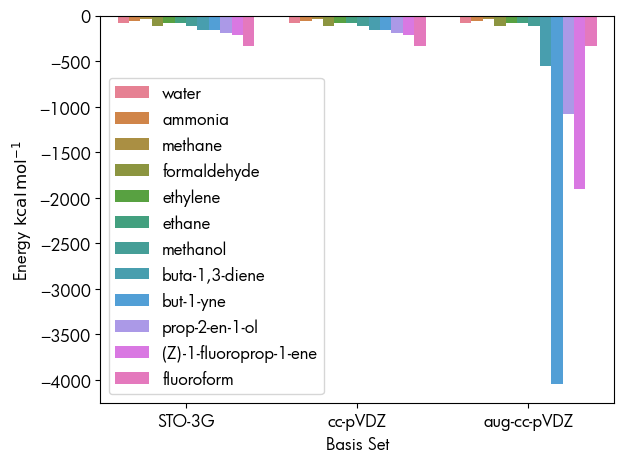

In [23]:
sns.barplot(data=upDF, x='Basis Set', y='Energy', hue='Molecule', errorbar=None)
#plt.xticks(rotation=360-45)
plt.ylabel(r"Energy $\mathrm{kcal\,mol^{-1}}$")
plt.tight_layout()
plt.legend(fontsize=12)
plt.show()

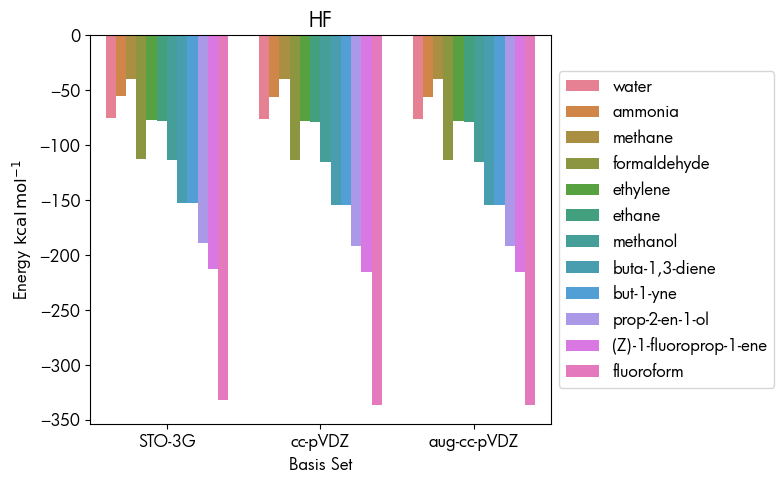

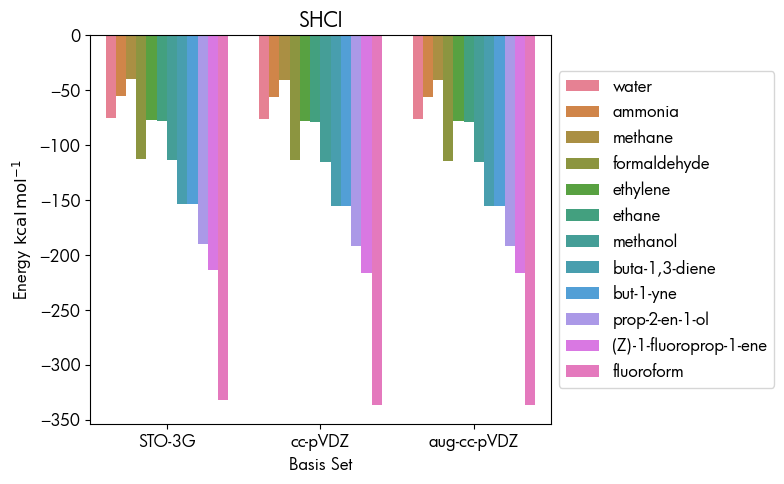

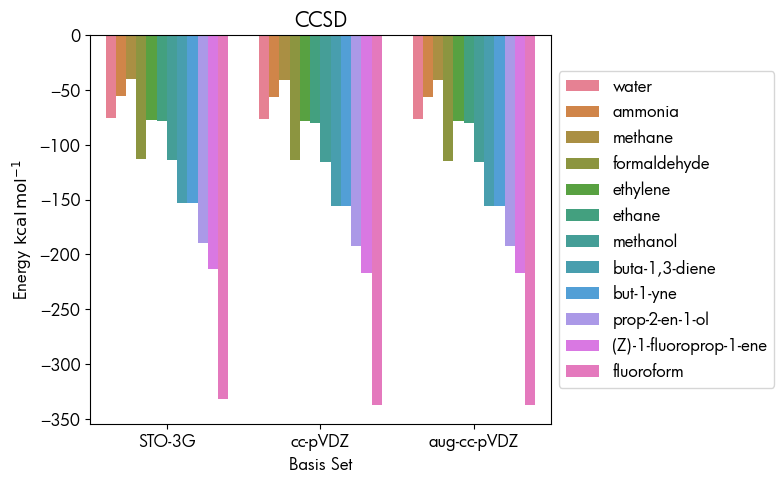

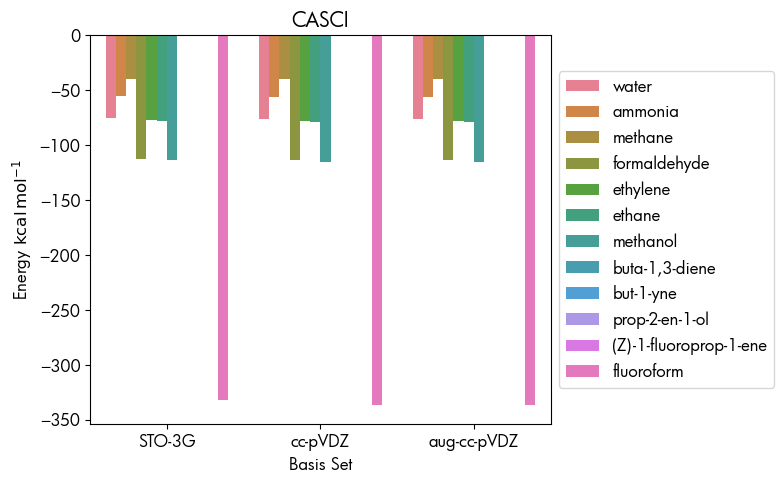

In [24]:
methods = ['HF', 'SHCI', 'CCSD', 'CASCI']

for method in methods:
    plt.figure(figsize=(8,5))
    subset = upDF[upDF['Method'] == method]
    sns.barplot(data=subset, x='Basis Set', y='Energy', hue='Molecule', errorbar=None)
    plt.title(method)
    #plt.xticks(rotation=360-45)
    
    plt.ylabel(r"Energy $\mathrm{kcal\,mol^{-1}}$")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    
    plt.show()

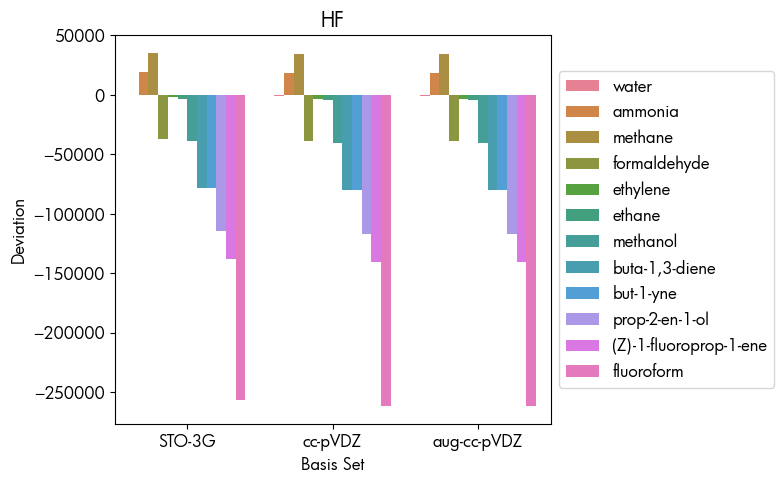

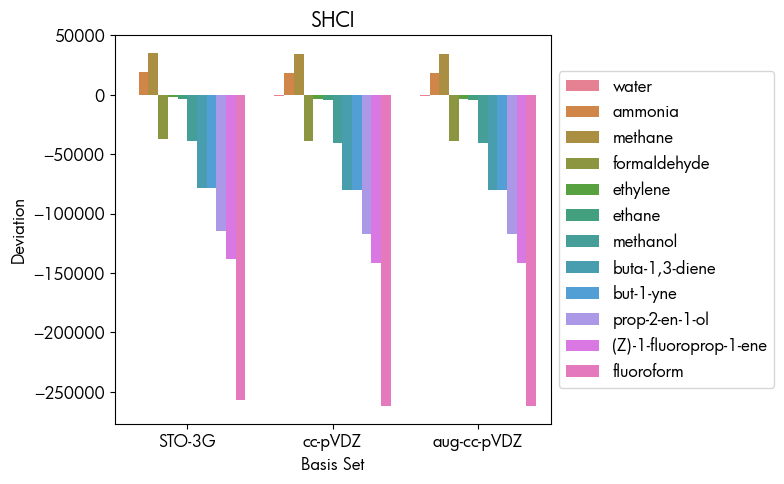

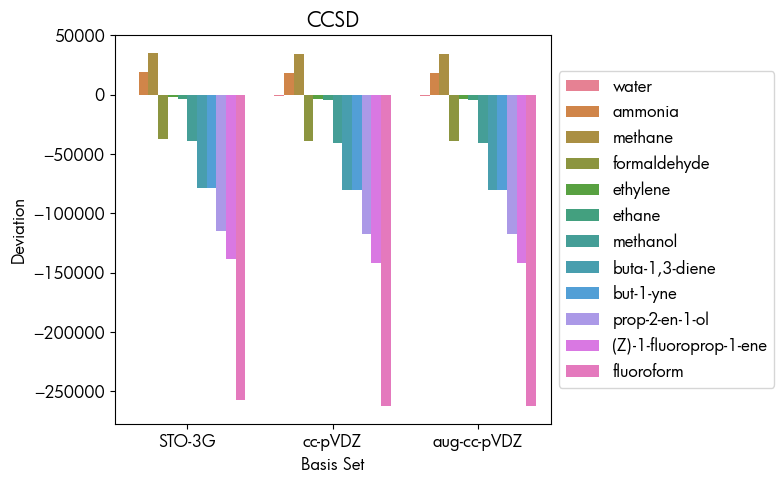

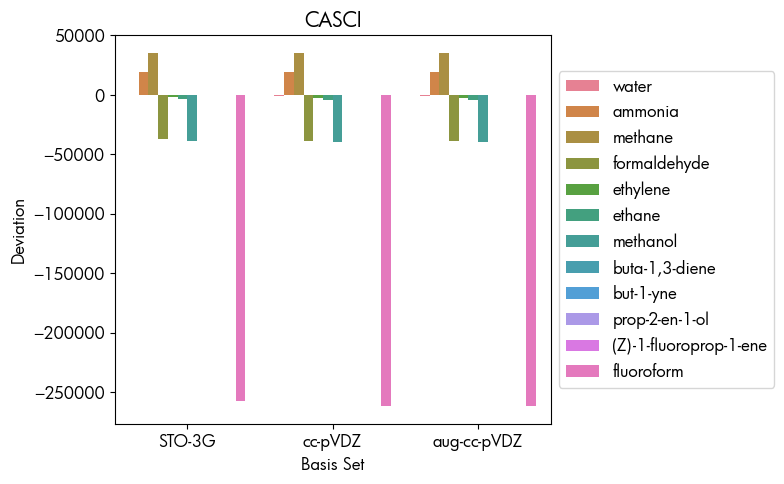

In [25]:
methods = ['HF', 'SHCI', 'CCSD', 'CASCI']

for method in methods:
    plt.figure(figsize=(8,5))
    subset = upDF[upDF['Method'] == method]
    sns.barplot(data=subset, x='Basis Set', y='Deviation', hue='Molecule', errorbar=None)
    plt.title(method)
    #plt.xticks(rotation=360-45)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    
    plt.show()

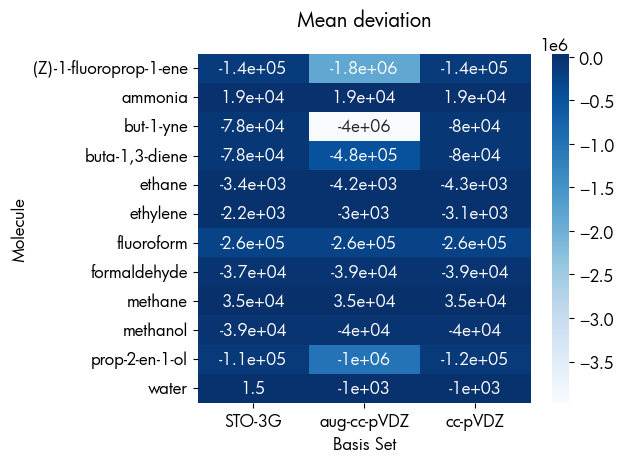

In [26]:
heatmap_data = upDF.pivot_table(values='Deviation', index='Molecule', columns='Basis Set', aggfunc='mean') # here aggfunc mean computes the mean deviation
sns.heatmap(heatmap_data, annot=True, cmap='Blues')
plt.title('Mean deviation', pad=20)
plt.tight_layout()
plt.show()

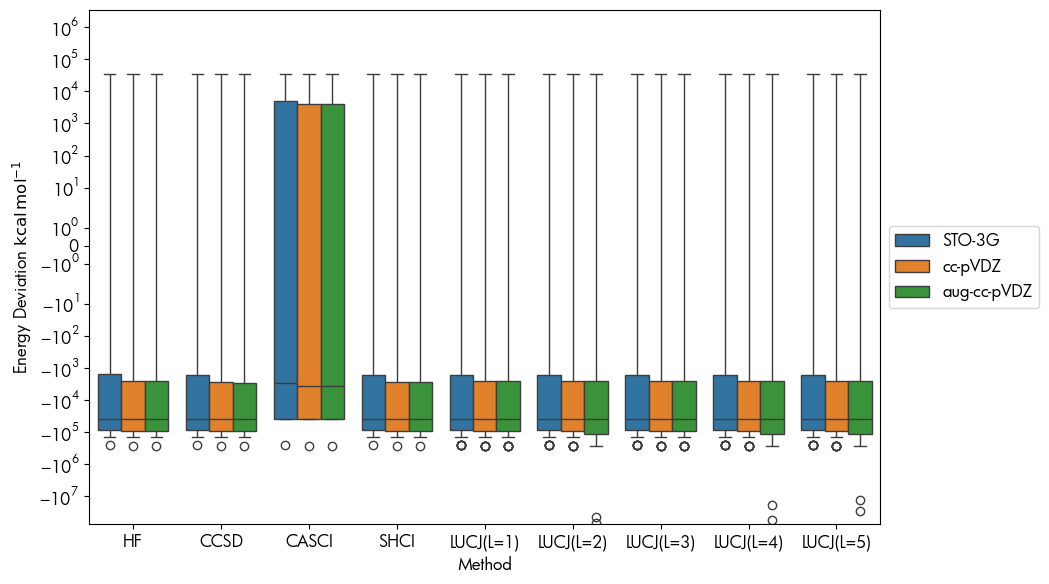

In [27]:
plt.figure(figsize=(9,6))
sns.boxplot(data=upDF, x='Method', y='Deviation', hue='Basis Set')
plt.yscale('symlog')
plt.tight_layout()

plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

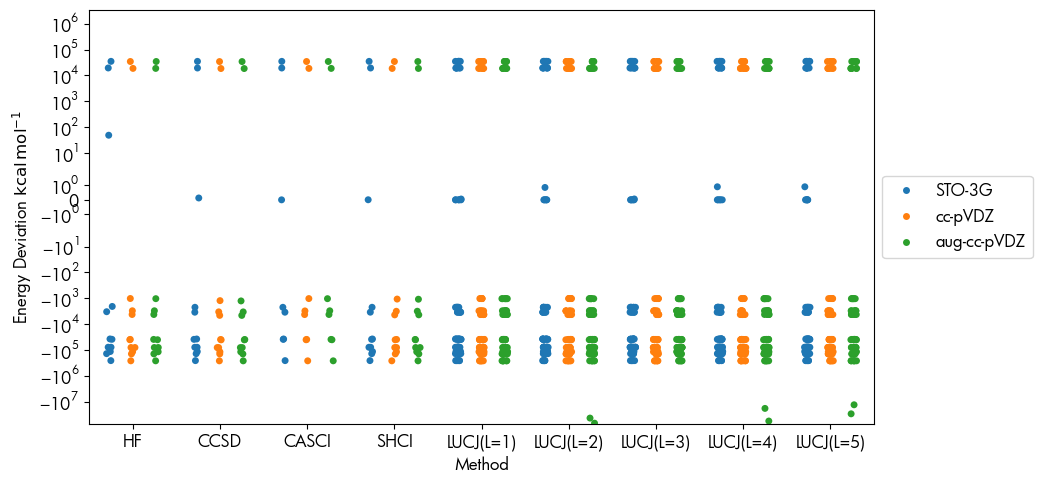

In [28]:
plt.figure(figsize=(9,5))
sns.stripplot(data=upDF, x='Method', y='Deviation', hue='Basis Set', dodge=True, jitter=True)
plt.yscale('symlog')

plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

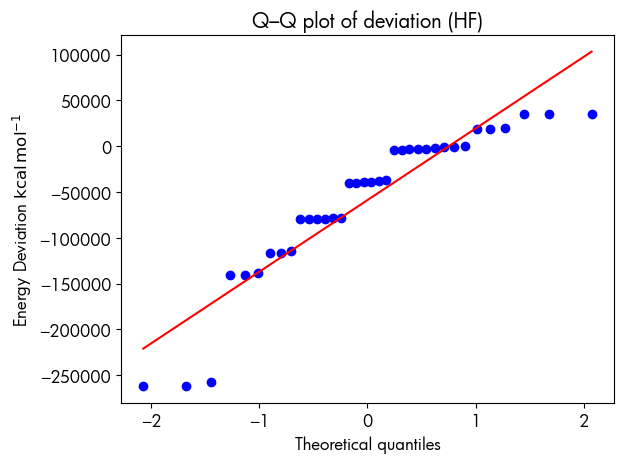

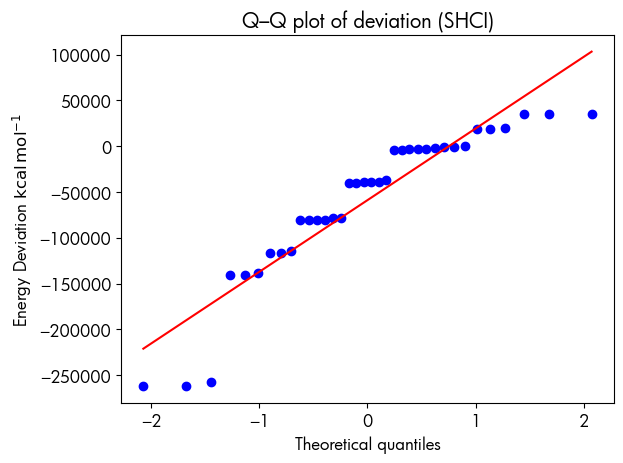

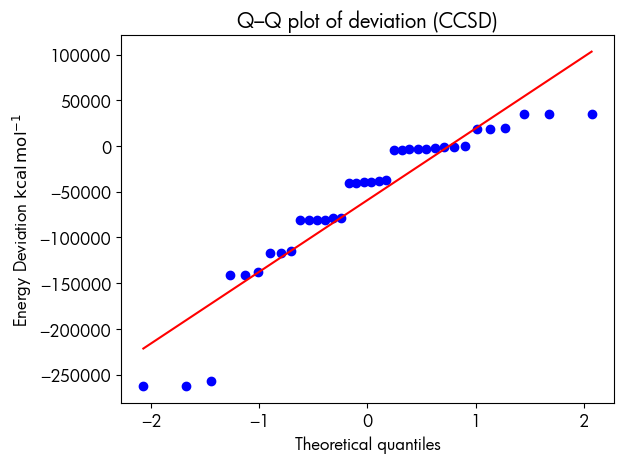

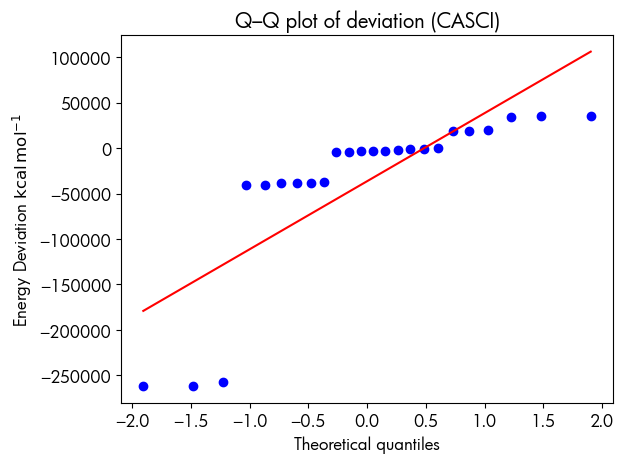

In [29]:
for method in methods:
    subset = upDF[upDF['Method'] == method]['Deviation'].dropna()
    stats.probplot(subset, dist="norm", plot=plt)
    plt.title(f"Q–Q plot of deviation ({method})")
    plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
    plt.tight_layout()
    plt.show()

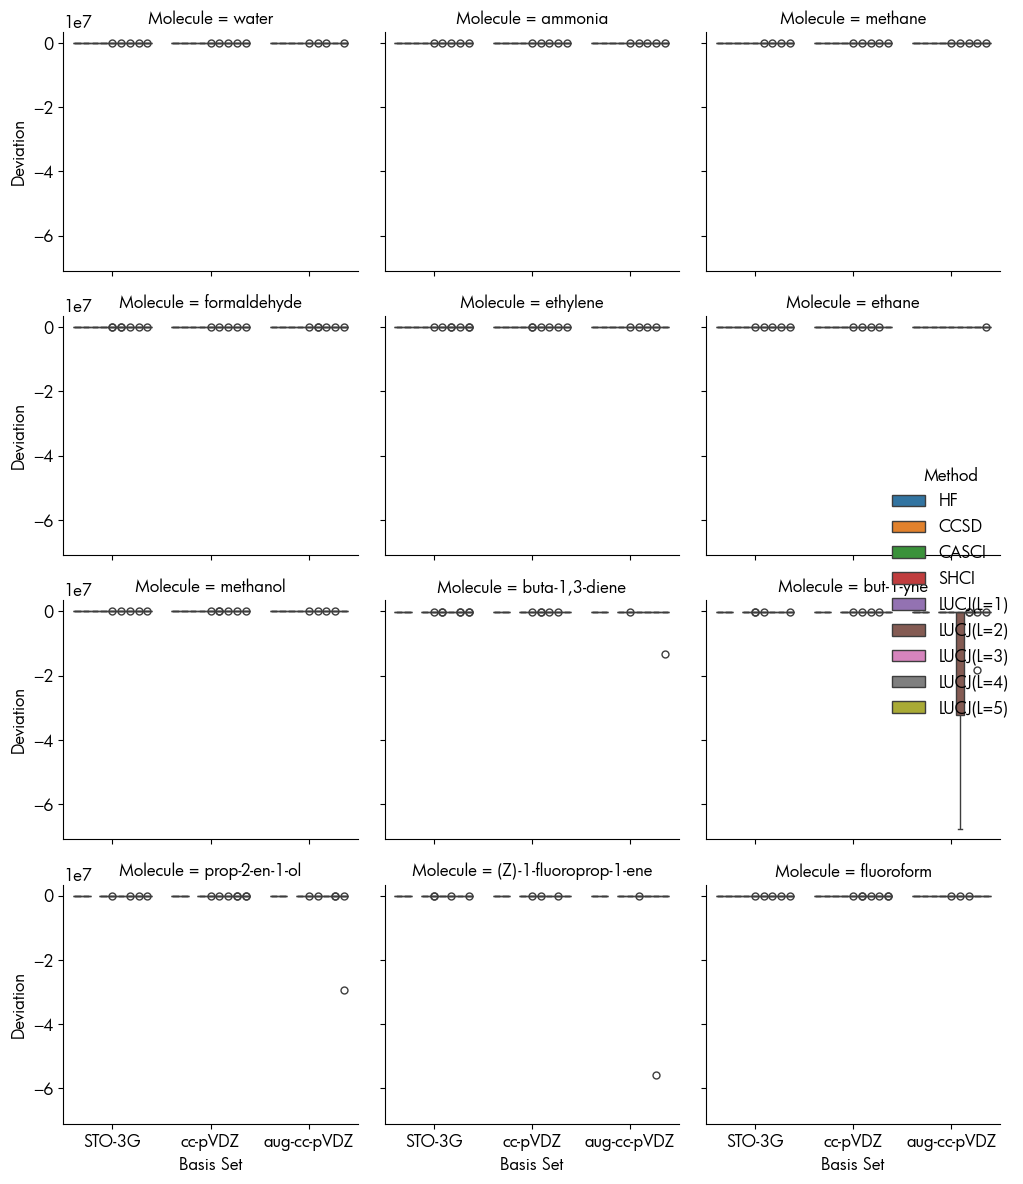

In [30]:
sns.catplot(data=upDF, x='Basis Set', y='Deviation', hue='Method', col='Molecule', kind='box', col_wrap=3, height=3)
plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
plt.tight_layout()
plt.show()

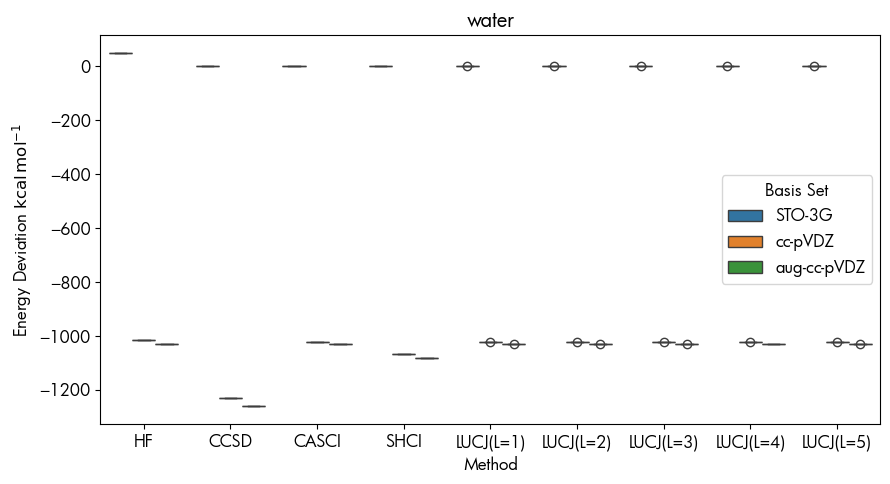

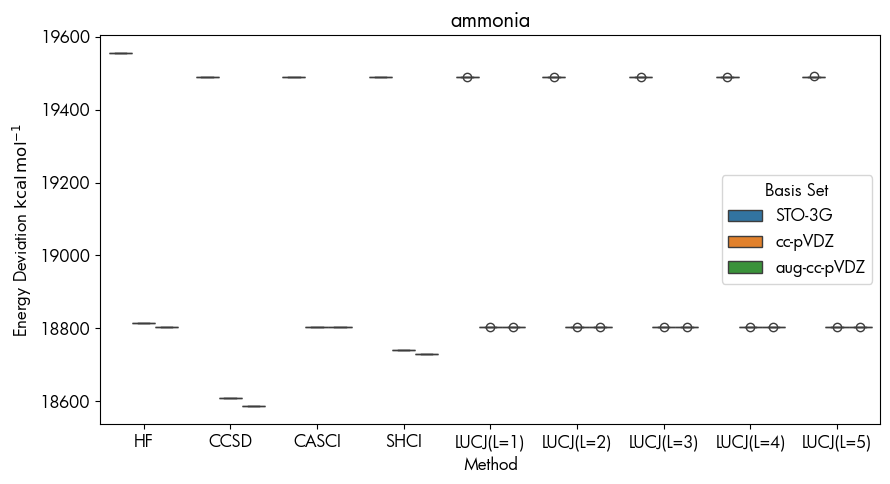

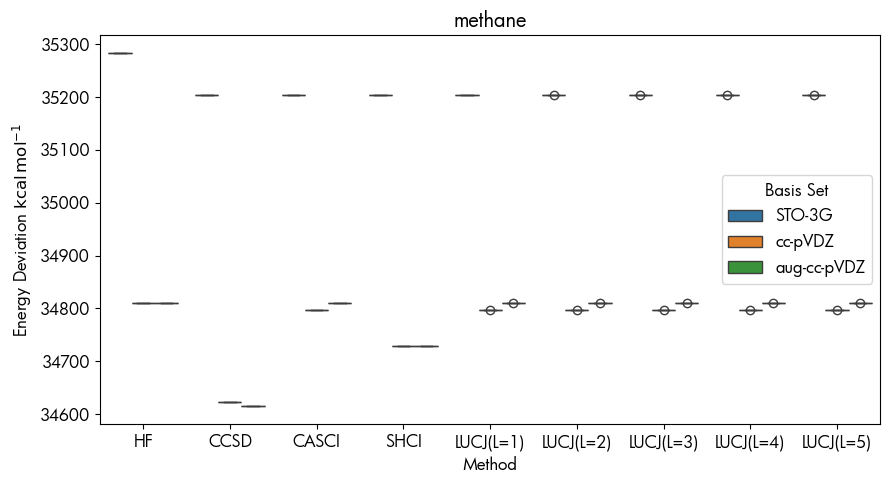

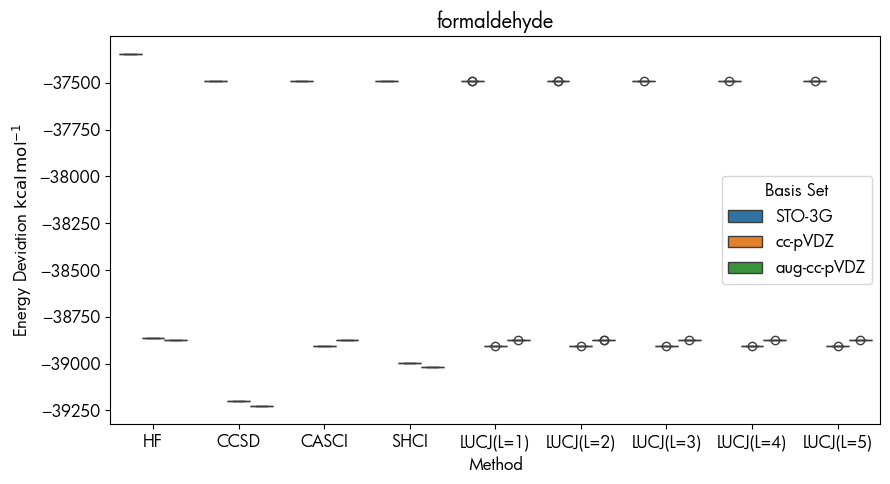

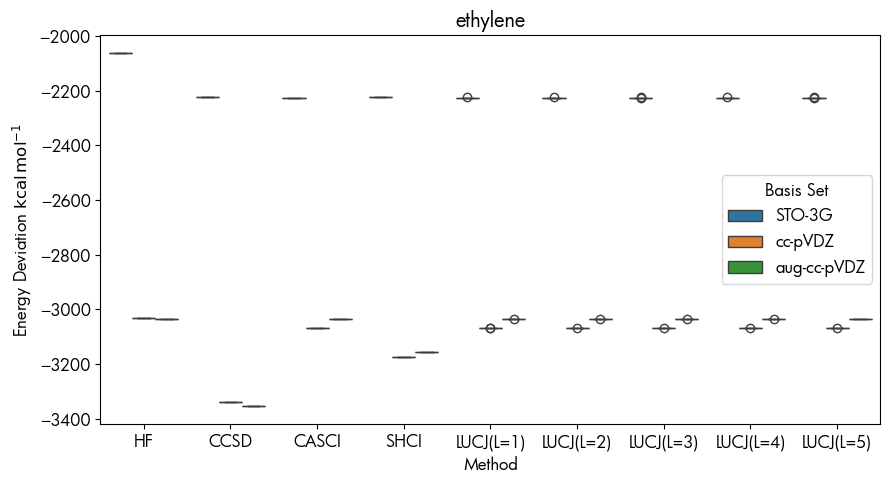

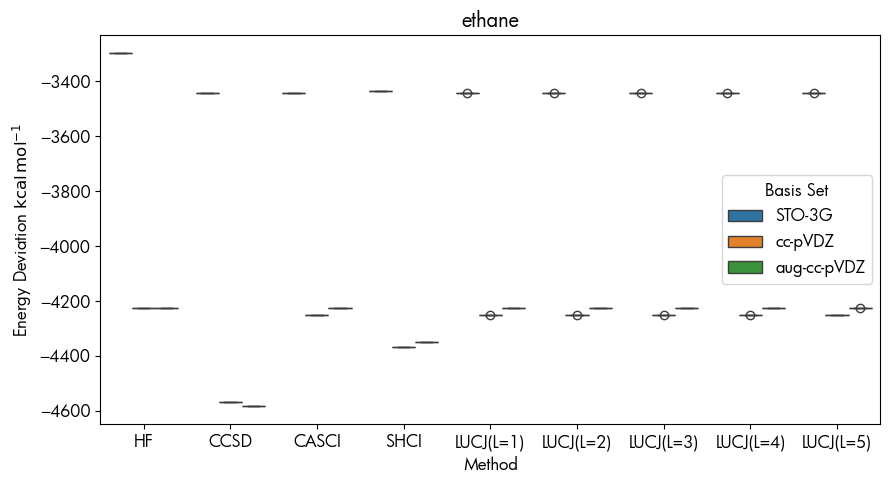

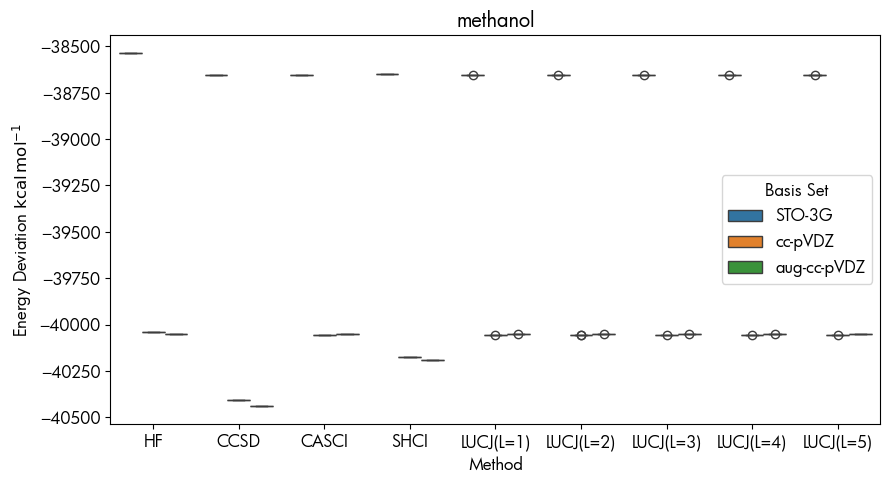

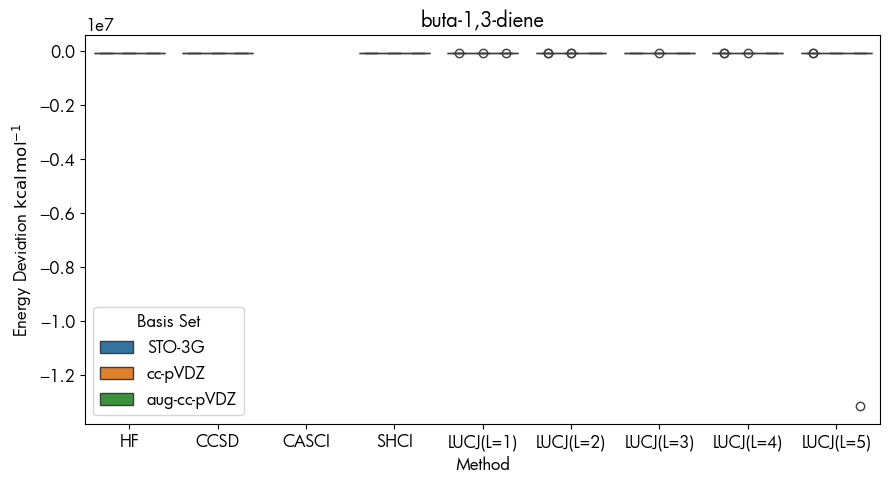

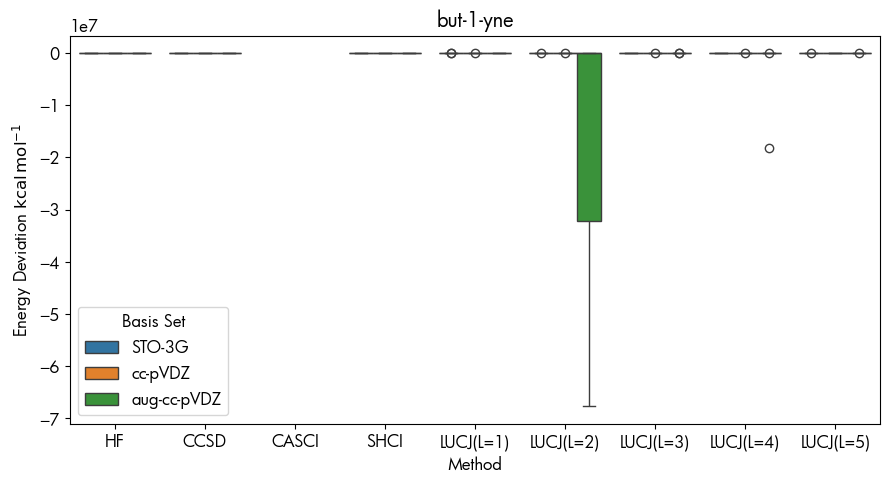

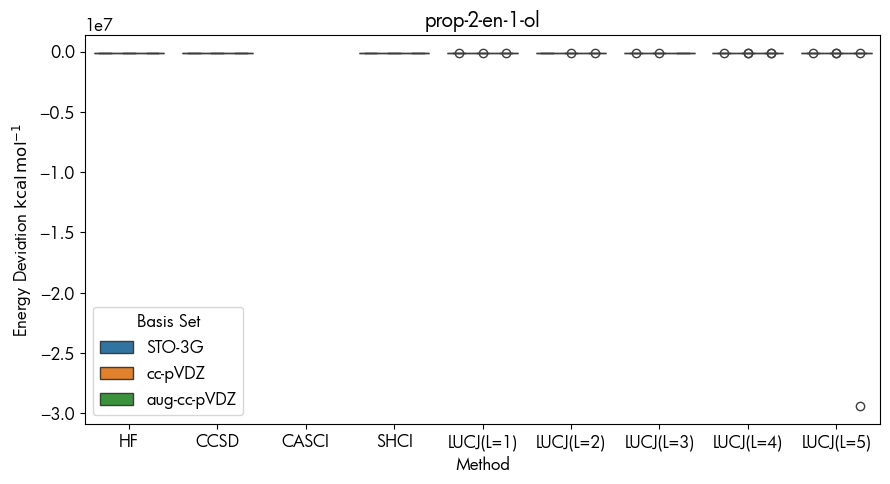

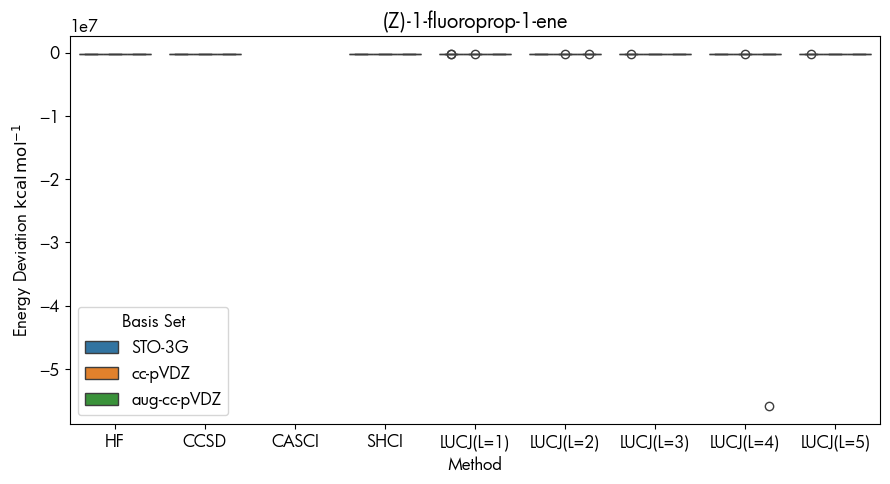

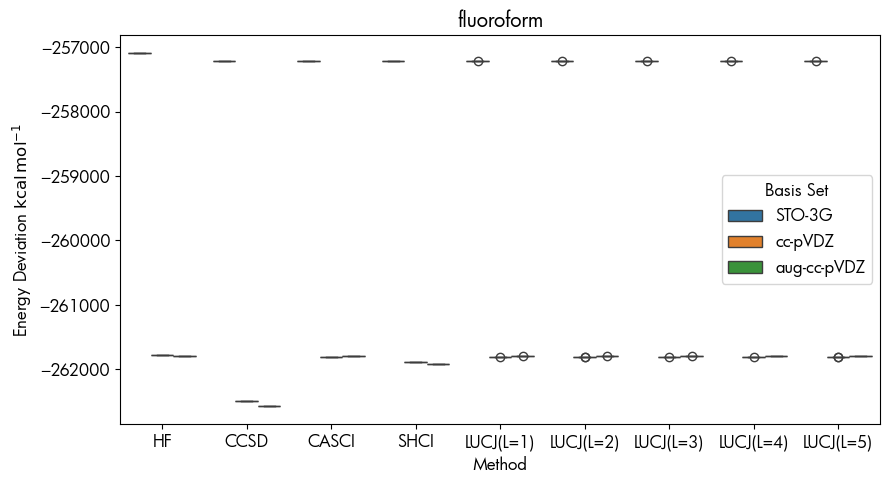

In [32]:
for mol in uniqueMol:
    plt.figure(figsize=(9, 5))
    sns.boxplot(
        data=upDF[upDF['Molecule'] == mol],
        x='Method', y='Deviation',
        hue='Basis Set'
    )
    #plt.yscale('symlog')
    plt.title(mol)
    plt.tight_layout() 
    plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
    plt.show()

In [33]:
n_atoms_dict = {
    'water': 3,
    'methane': 5,
    'ammonia': 4,
    'ethane': 8,
    'methanol': 6,
    'ethylene': 6,
    'formaldehyde': 4
}

upDF['n_atoms'] = upDF['Molecule'].map(n_atoms_dict)

In [34]:
upDF.head()

,Basis Set,Molecule,Method,Energy,L,Injected,Deviation,n_atoms
0,STO-3G,water,HF,-74.960552,NaN,NaN,48.926714,3.0
1,STO-3G,water,CCSD,-75.009350,NaN,NaN,0.129131,3.0
2,STO-3G,water,CASCI,-75.009479,NaN,NaN,0.000000,3.0
3,STO-3G,water,SHCI,-75.009474,NaN,NaN,0.005023,3.0
4,STO-3G,ammonia,HF,-55.454318,NaN,NaN,19555.160859,4.0


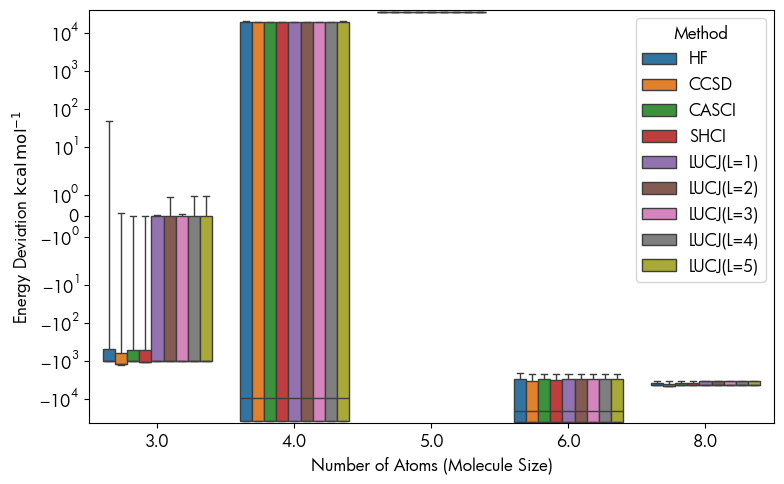

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=upDF,
    x='n_atoms',
    y='Deviation',
    hue='Method'
)
plt.yscale('symlog')
plt.xlabel("Number of Atoms (Molecule Size)")

plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
plt.tight_layout()
plt.show()


/tmp/ipykernel_5971/1029970013.py:13: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(


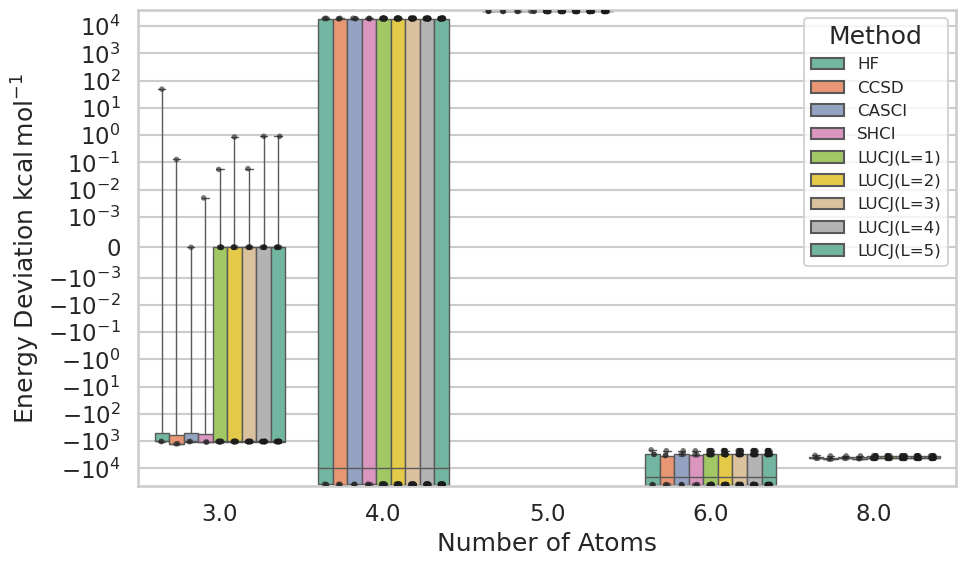

In [36]:
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=upDF,
    x='n_atoms',
    y='Deviation',
    hue='Method',
    palette='Set2',
    fliersize=0 
)
sns.stripplot(
    data=upDF,
    x='n_atoms',
    y='Deviation',
    hue='Method',
    dodge=True,
    color='k',
    alpha=0.6,
    size=4
)

plt.yscale('symlog', linthresh=1e-3)
plt.xlabel("Number of Atoms")
plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:len(upDF['Method'].unique())], labels[:len(upDF['Method'].unique())], title="Method", fontsize=12)

plt.tight_layout()
plt.show()

In [37]:
upDF

,Basis Set,Molecule,Method,Energy,L,Injected,Deviation,n_atoms
0,STO-3G,water,HF,-74.960552,NaN,NaN,4.892671e+01,3.0
1,STO-3G,water,CCSD,-75.009350,NaN,NaN,1.291311e-01,3.0
2,STO-3G,water,CASCI,-75.009479,NaN,NaN,0.000000e+00,3.0
3,STO-3G,water,SHCI,-75.009474,NaN,NaN,5.023047e-03,3.0
4,STO-3G,ammonia,HF,-55.454318,NaN,NaN,1.955516e+04,4.0
...,...,...,...,...,...,...,...,...
1219,STO-3G,water,LUCJ(L=5),-75.009479,5.0,ML,-4.027356e-08,3.0
1220,STO-3G,water,LUCJ(L=5),-75.009479,5.0,ML_exact,-3.088019e-08,3.0
1221,STO-3G,water,LUCJ(L=5),-75.009479,5.0,MP2,-4.358469e-08,3.0
1222,STO-3G,water,LUCJ(L=5),-75.009479,5.0,random,-4.366996e-08,3.0


/tmp/ipykernel_5971/2596397980.py:10: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(


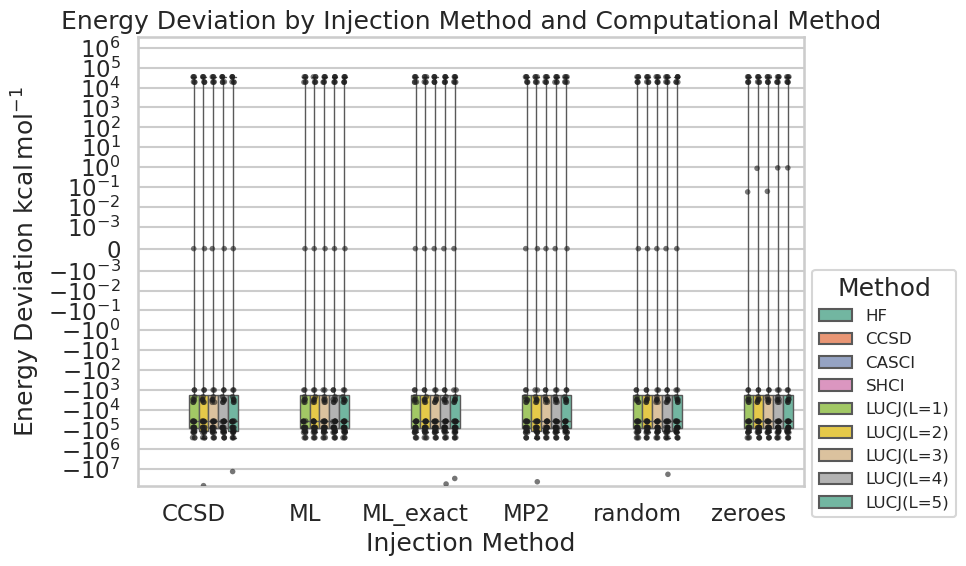

In [38]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=upDF,
    x='Injected',      # categorical injection method
    y='Deviation',
    hue='Method',
    palette='Set2',
    fliersize=0
)
sns.stripplot(
    data=upDF,
    x='Injected',
    y='Deviation',
    hue='Method',
    dodge=True,
    color='k',
    alpha=0.6,
    size=4
)

plt.yscale('symlog', linthresh=1e-3)
plt.xlabel("Injection Method")
plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
plt.title("Energy Deviation by Injection Method and Computational Method")

# Simplify legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:len(upDF['Method'].unique())], labels[:len(upDF['Method'].unique())], title="Method", fontsize=12, bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 75.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 62.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 95.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 94.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


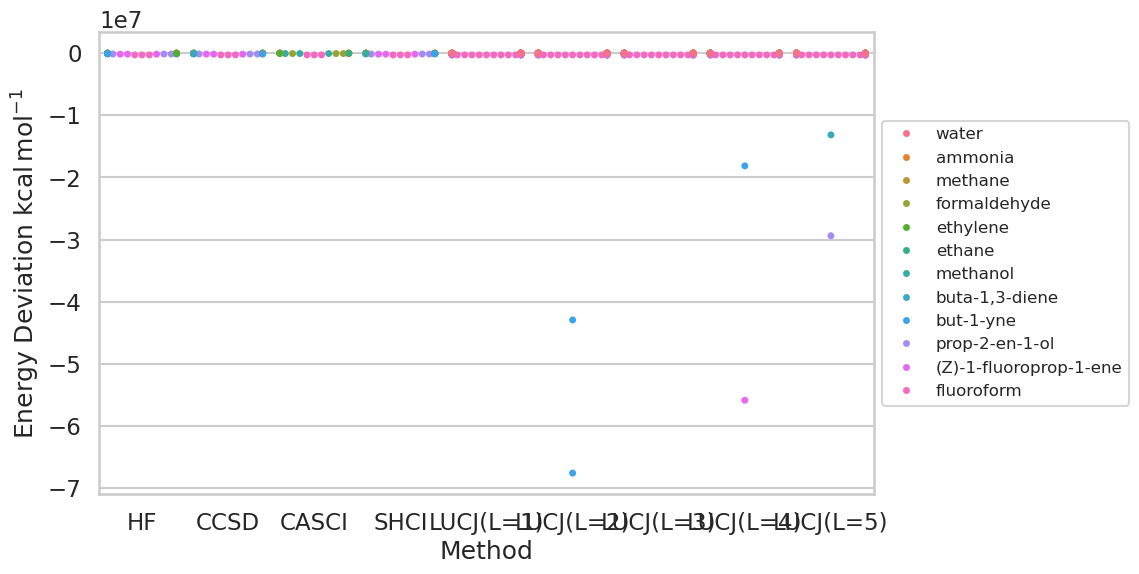

In [39]:
plt.figure(figsize=(10, 6))
sns.swarmplot(
    data=upDF,
    x='Method',
    y='Deviation',
    hue='Molecule'
)

plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
plt.show()

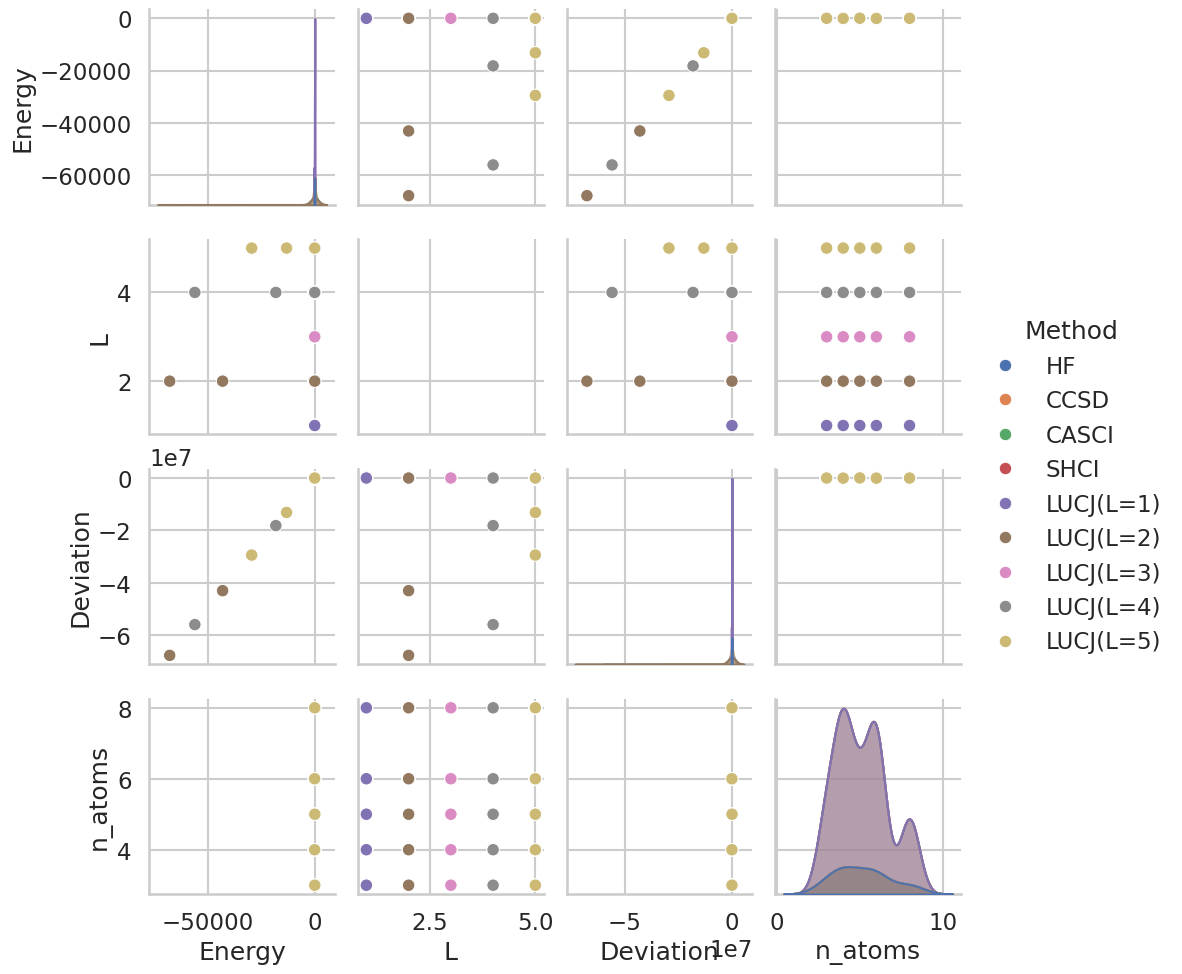

In [40]:
sns.pairplot(upDF, hue="Method")